In [1]:
_repo_root = !git rev-parse --show-toplevel
%cd -q {_repo_root[0]}
del _repo_root

# Bivariate fitting

Loads, validates, summarizes, and plots persisted bivariate experiment results.
Curves show median test RMSE across seeds; shaded bands span the 25th to 75th percentiles.

In [2]:
import matplotlib as mpl
import pandas as pd

from paper.experiments import bivariate, synthetic
from paper.plotting import plot_bivariate_target_gallery, plot_scaling
from paper.targets import TargetSpec

mpl.rcParams["figure.dpi"] = 140

In [3]:
profile_name = "full"
profile = bivariate.PROFILES[profile_name]
raw_path = synthetic.default_raw_path("bivariate", profile_name)

In [4]:
if not raw_path.exists():
    raise FileNotFoundError(
        f"{raw_path} does not exist; run paper.experiments.bivariate first"
    )

raw = pd.read_csv(raw_path)
synthetic.validate_raw(raw, profile)
summary = synthetic.summarize_results(raw)
summary.head()

,target_kind,complexity,noise_std,model,dim,batch_size,train_size,selected_lr,median_test_rmse,q25_test_rmse,q75_test_rmse,n
0,general,5,0.0,unconstrained,5,32,32,0.1,1.102673,0.960948,1.222481,96
1,general,5,0.0,unconstrained,5,32,64,0.1,0.990442,0.874366,1.106829,96
2,general,5,0.0,unconstrained,5,32,160,0.1,0.799761,0.690771,0.945563,96
3,general,5,0.0,unconstrained,5,32,320,0.1,0.723463,0.619274,0.833432,96
4,general,5,0.0,unconstrained,5,32,640,0.1,0.606181,0.519915,0.690779,96


## General targets

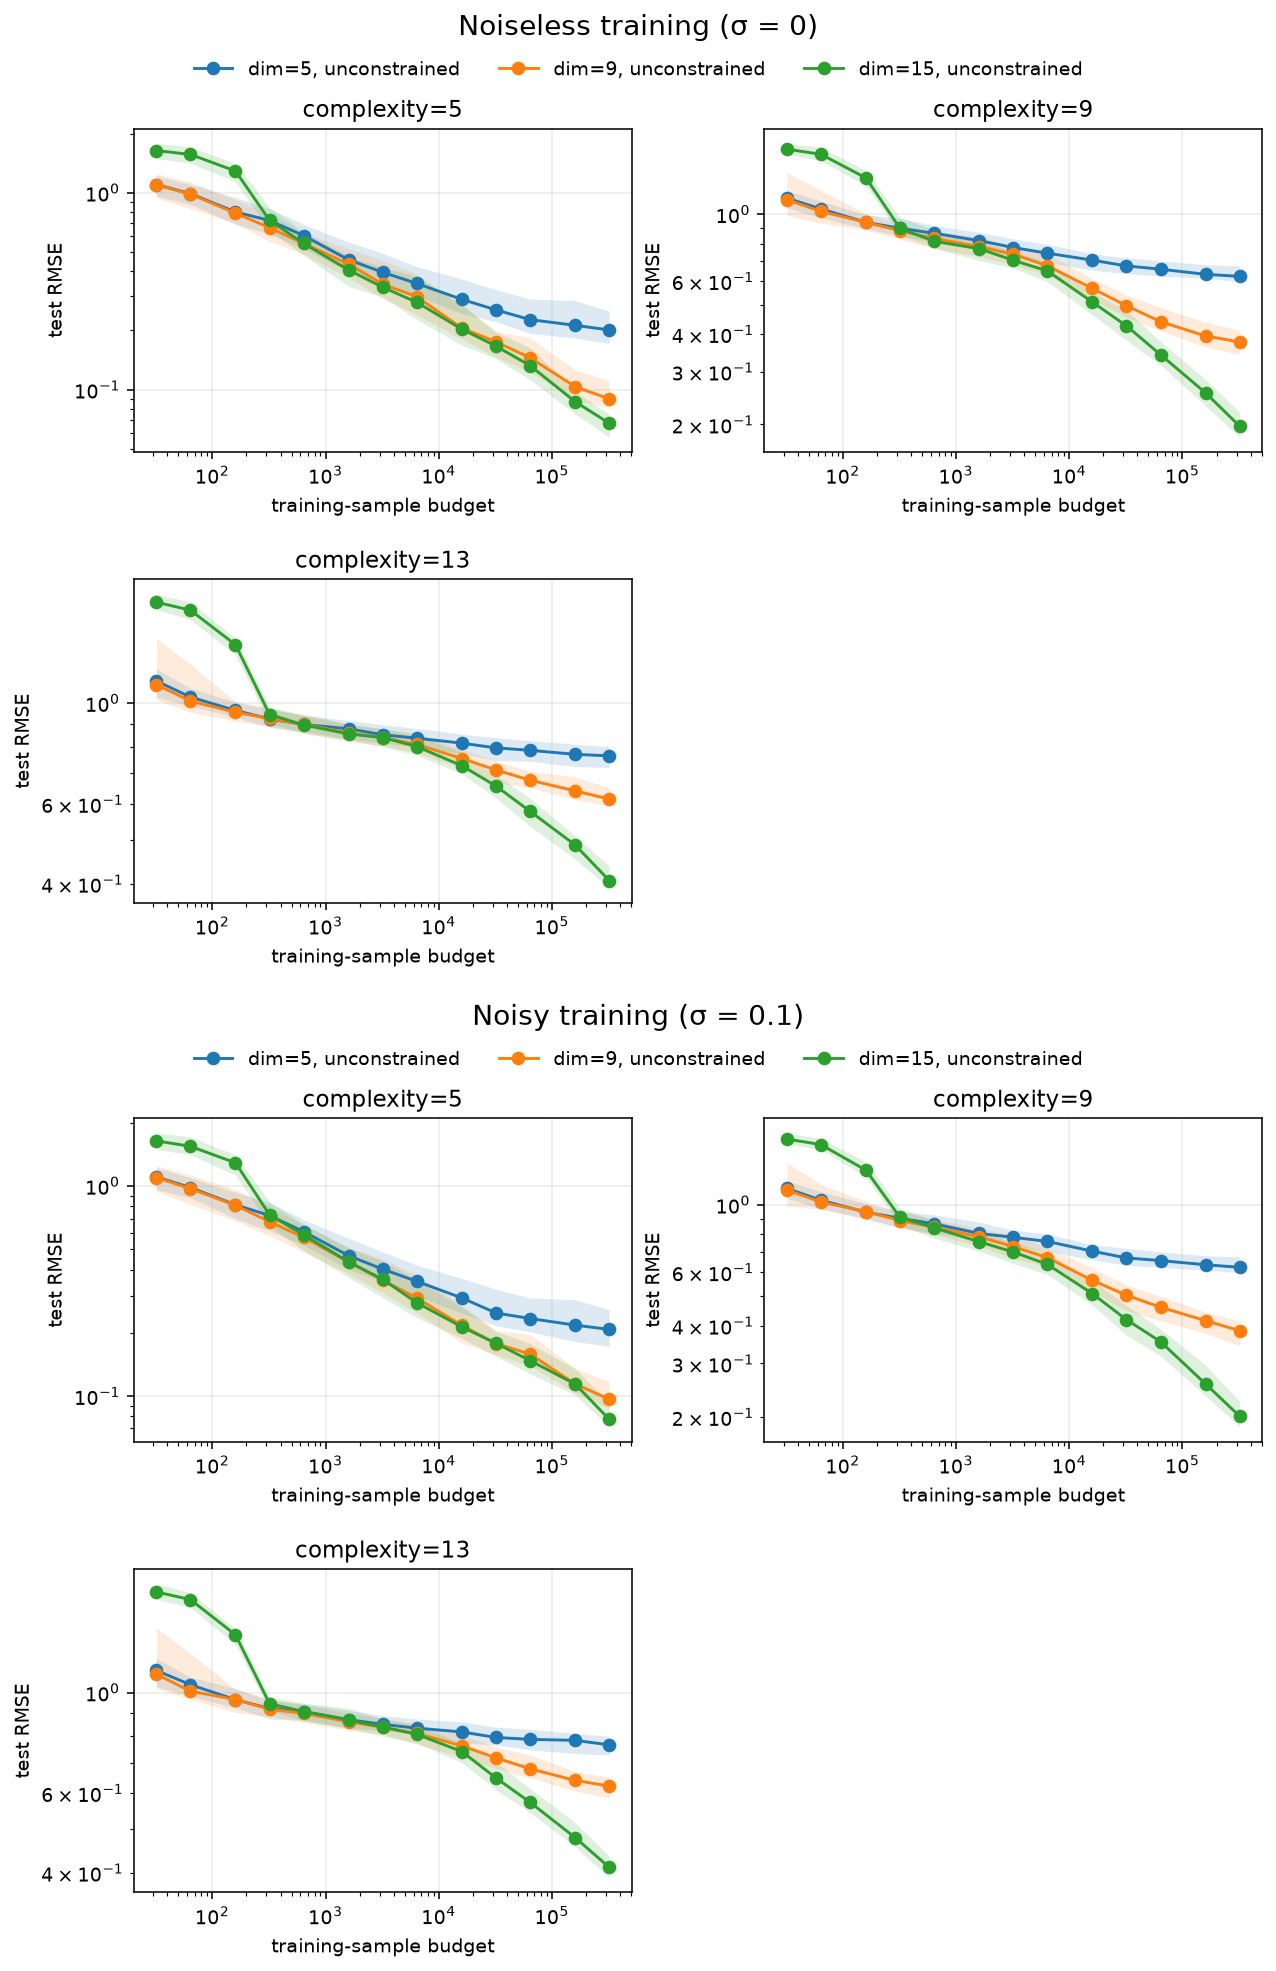

In [5]:
general_summary = summary.loc[summary["target_kind"] == "general"]
plot_scaling(general_summary);

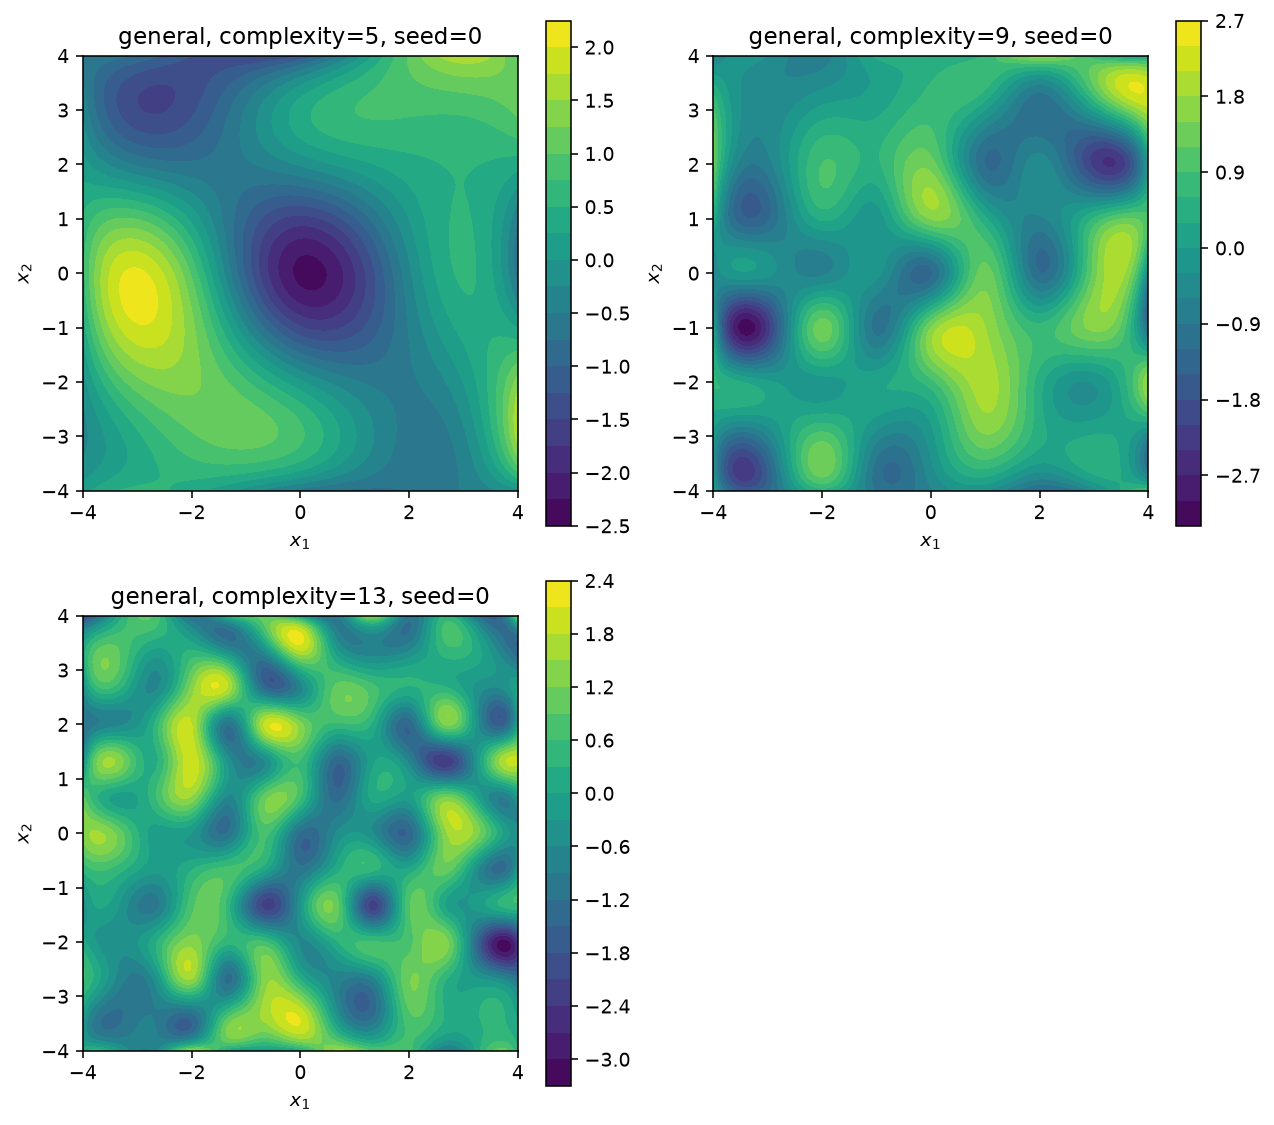

In [6]:
plot_bivariate_target_gallery([
    TargetSpec(kind="general", complexity=complexity, seed=0)
    for complexity in sorted(general_summary["complexity"].unique())
]);

## Monotone targets

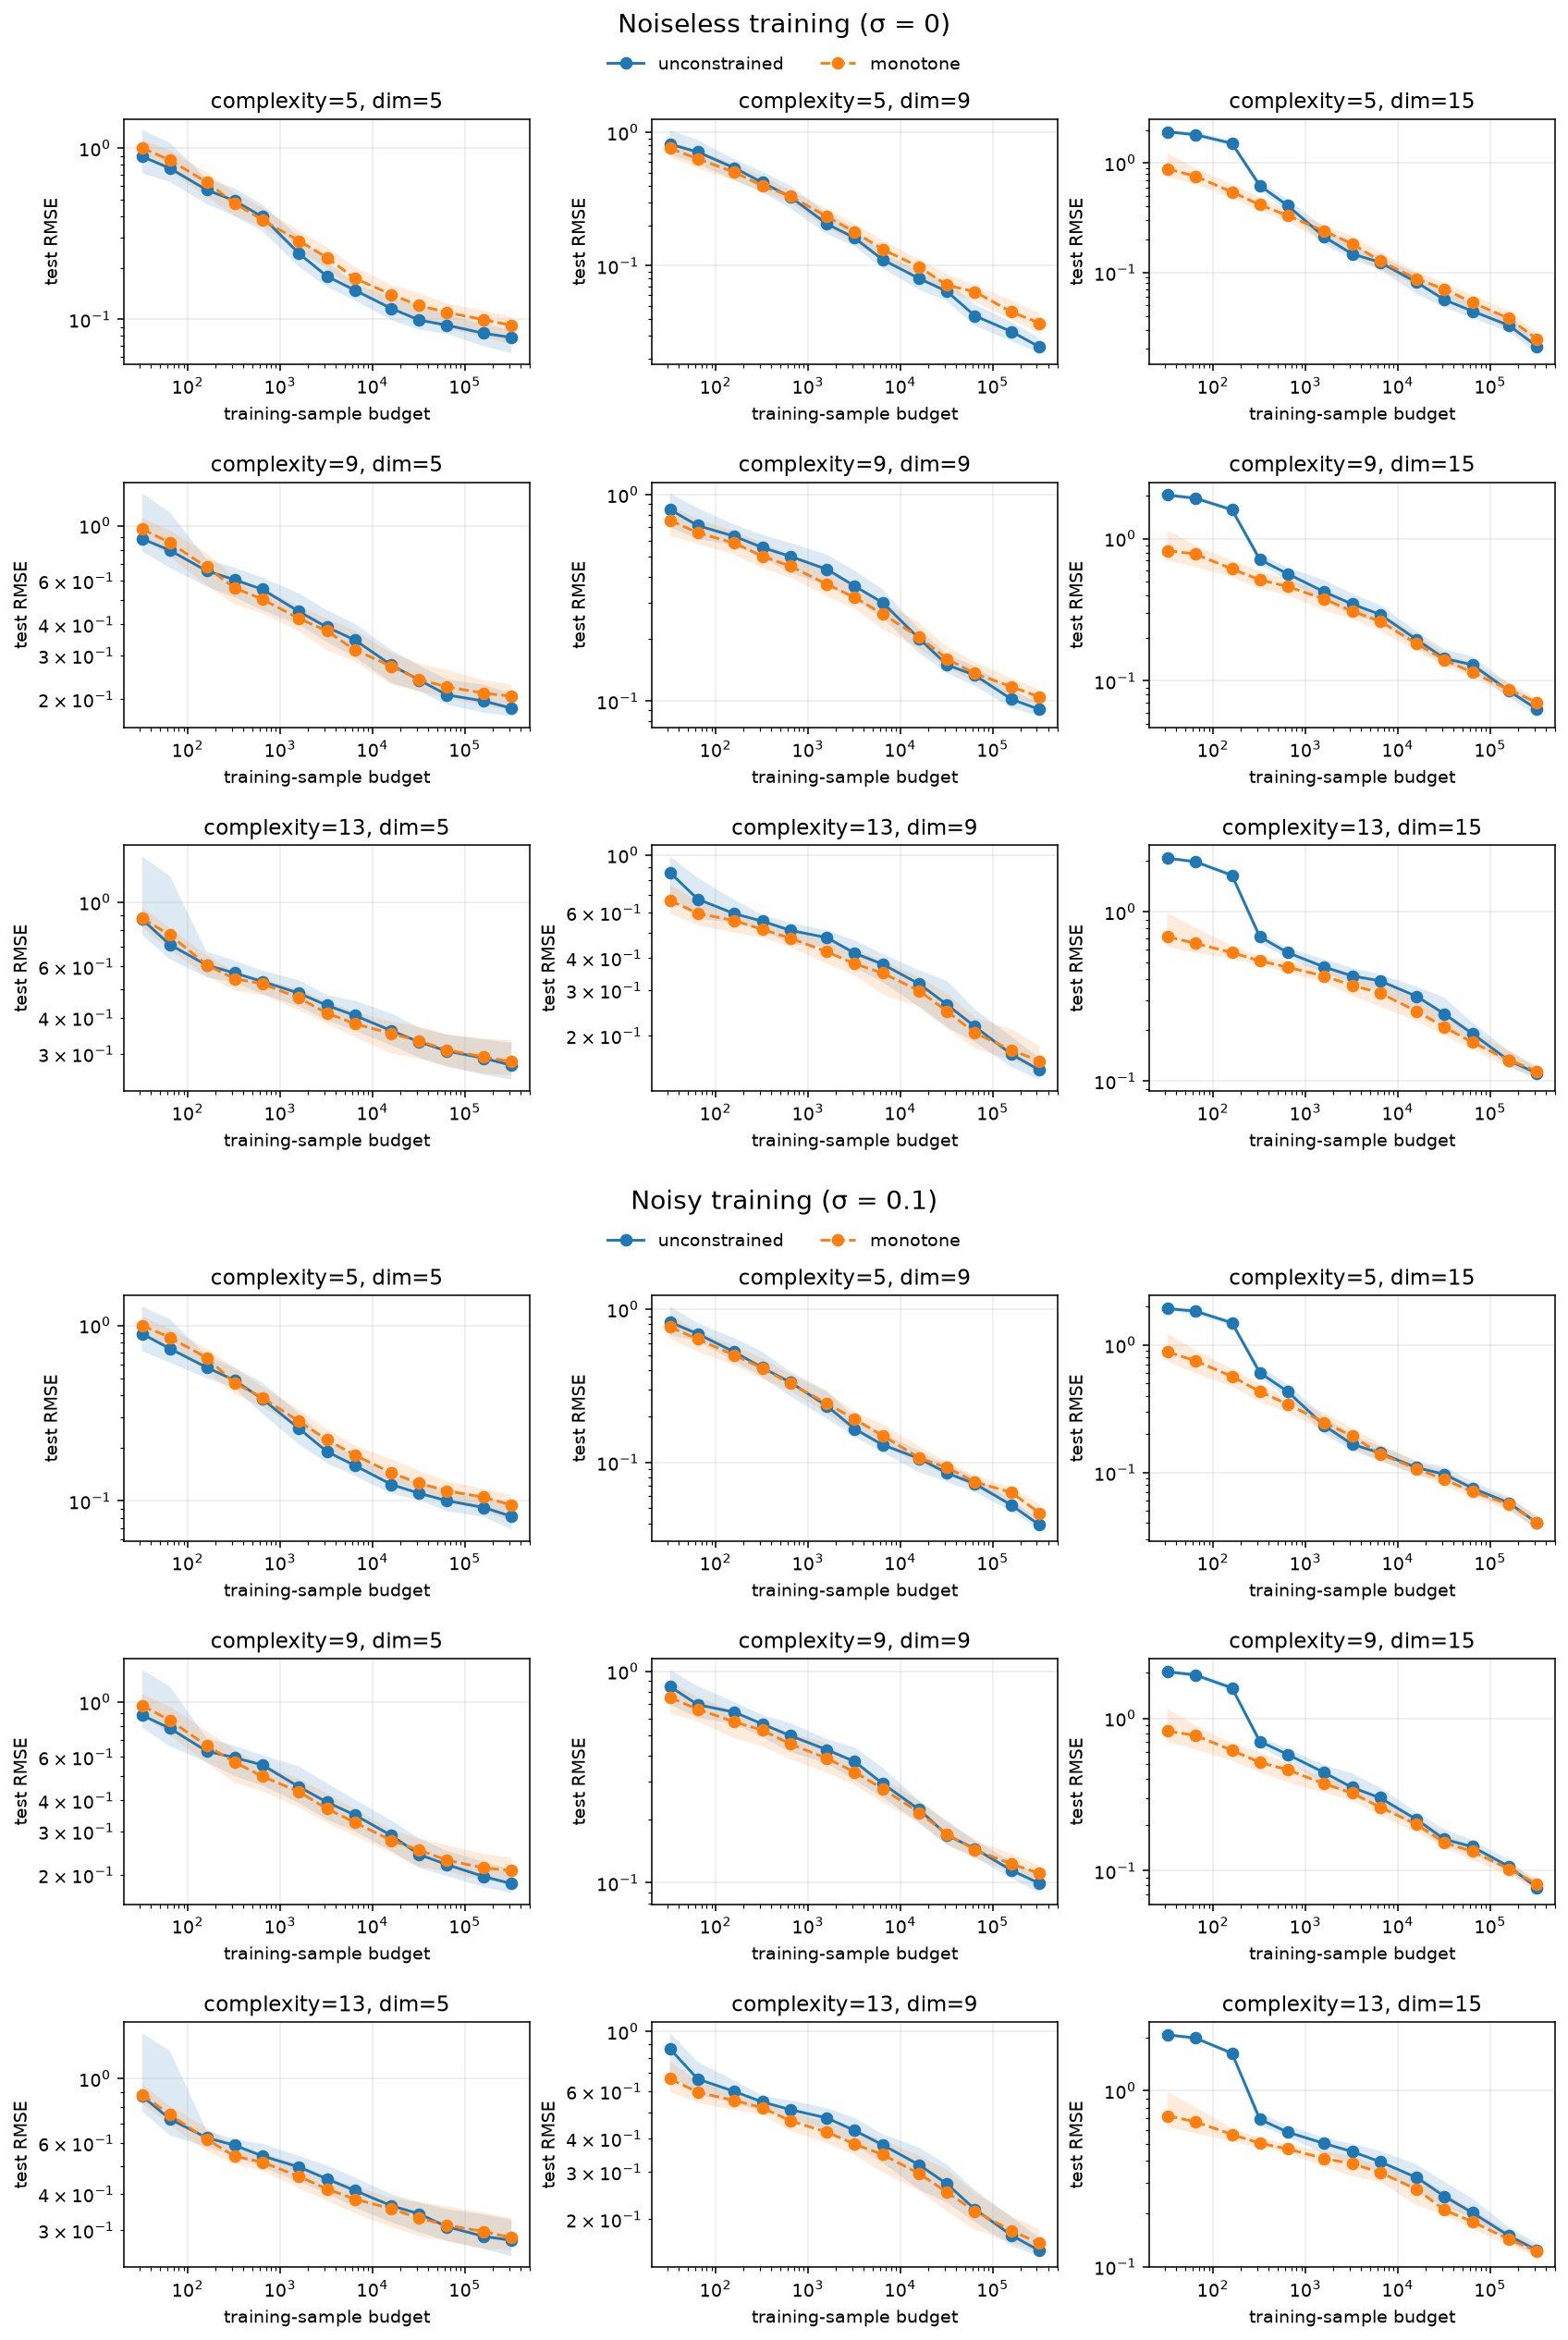

In [7]:
monotone_summary = summary.loc[summary["target_kind"] == "monotone"]
plot_scaling(monotone_summary);

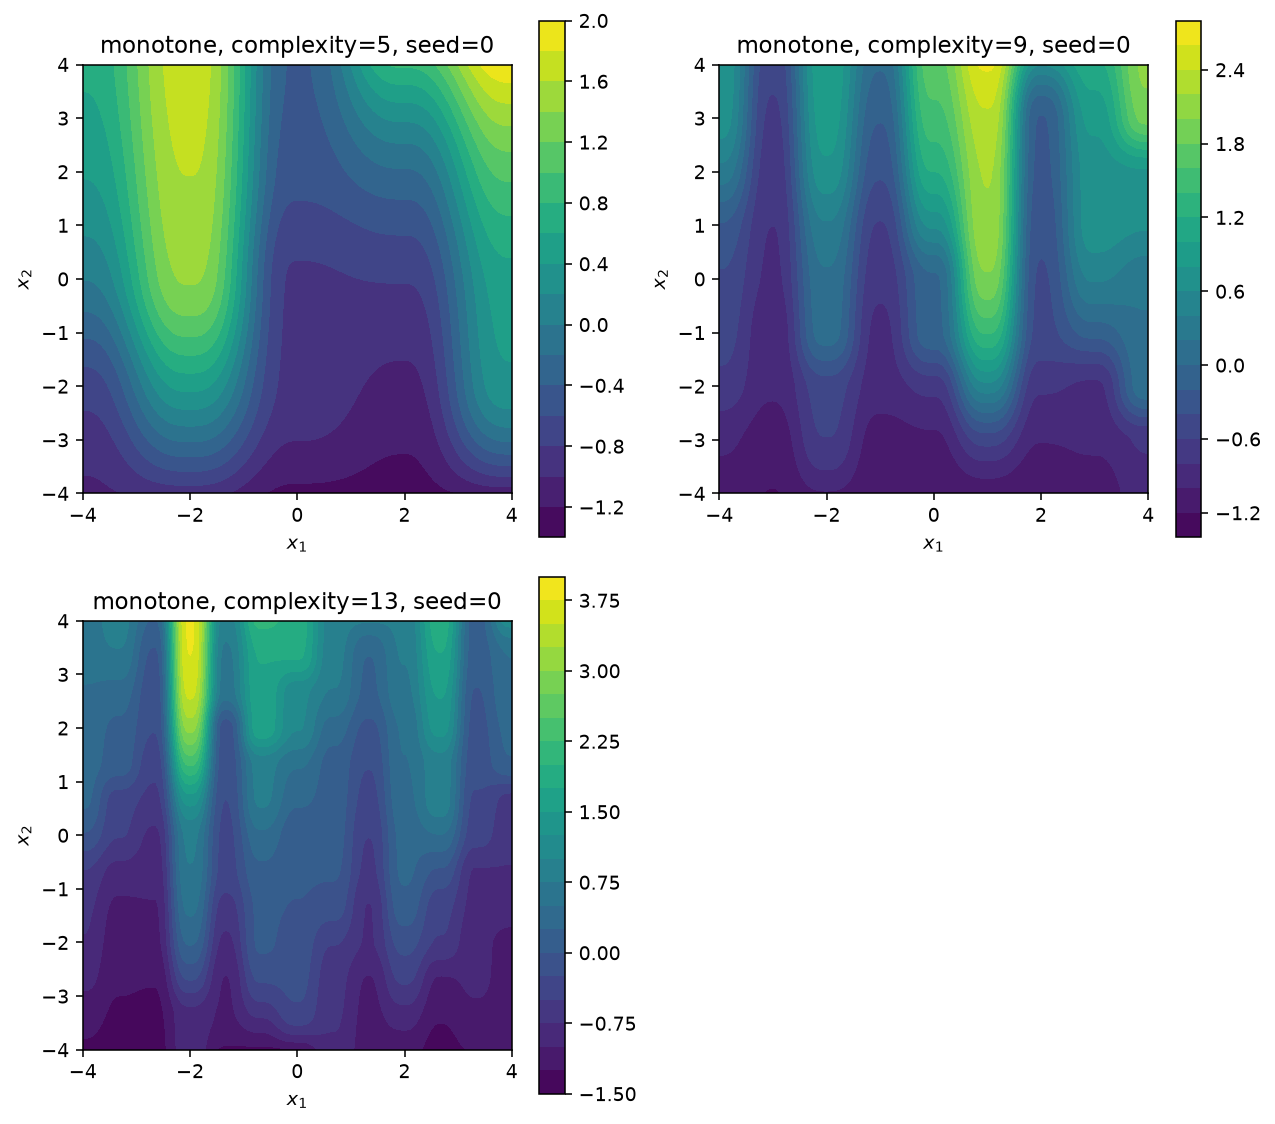

In [8]:
plot_bivariate_target_gallery([
    TargetSpec(kind="monotone", complexity=complexity, seed=0)
    for complexity in sorted(monotone_summary["complexity"].unique())
]);